# CM1(2) - Excel coursework (2025/26)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyliferisk import *
from pyliferisk.mortalitytables import AM92
from plotnine import *


# Set display options for pandas to make tables easier to read
pd.set_option("display.max_columns", None)

## Question 1


### i and ii: Extending the Life Table


In [ ]:
# Load the mortality data
df = pd.read_csv("AM92csv.csv", skiprows=4, names=["Age", "q_[x]", "q_[x-1]+1", "q_x"])
df = df.dropna(subset=["Age"]).reset_index(drop=True)
df["Age"] = df["Age"].astype(int)
idx = {int(age): i for i, age in enumerate(df["Age"])}

# convert q columns to numeric
df["q_x"] = pd.to_numeric(df["q_x"], errors="coerce")
df["q_[x]"] = pd.to_numeric(df["q_[x]"], errors="coerce")
df["q_[x-1]+1"] = pd.to_numeric(df["q_[x-1]+1"], errors="coerce")

# --- Build ultimate and select l_x ---
radix = 10000.0
df["l_x"] = 0.0
df.at[0, "l_x"] = radix

for i in range(1, len(df)):
    l_prev = np.float64(df["l_x"].iloc[i - 1])
    q_prev = np.float64(df["q_x"].iloc[i - 1])
    df.at[i, "l_x"] = l_prev * (1.0 - q_prev)

for i in range(len(df)):
    age = int(df["Age"].iloc[i])
    q1 = df["q_[x-1]+1"].iloc[i]
    if age <= 91 and pd.notna(q1) and (i + 1 < len(df)):
        df.at[i, "l_[x-1]+1"] = np.float64(df["l_x"].iloc[i + 1]) / (
            1.0 - np.float64(q1)
        )

for i in range(len(df)):
    age = int(df["Age"].iloc[i])
    q0 = df["q_[x]"].iloc[i]
    if age <= 90 and pd.notna(q0) and (i + 1 < len(df)):
        df.at[i, "l_[x]"] = np.float64(df["l_[x-1]+1"].iloc[i + 1]) / (
            1.0 - np.float64(q0)
        )

df[["Age", "l_[x]", "l_[x-1]+1", "l_x"]].head()

,Age,l_[x],l_[x-1]+1,l_x
0,17,"9,997.81","9,999.52","10,000.00"
1,18,"9,991.89","9,993.54","9,994.00"
2,19,"9,986.04","9,987.63","9,988.06"
3,20,"9,980.24","9,981.79","9,982.20"
4,21,"9,974.50","9,976.00","9,976.39"


In [ ]:
# --- Verify 10p[50] and 10p50 ---
# .index lookup instead of hardcoded indices
# opted not to nest to avoid mixing up values
idx_50 = df.index[df["Age"] == 50][0]
idx_60 = df.index[df["Age"] == 60][0]

l_x_60 = np.float64(df["l_x"].iloc[idx_60])
l_select_50 = np.float64(df["l_[x]"].iloc[idx_50])
l_ult_50 = np.float64(df["l_x"].iloc[idx_50])

p10_select_50 = l_x_60 / l_select_50
p10_ult_50 = l_x_60 / l_ult_50

print(f"10p[50] = {p10_select_50:.6f}")
print(f"10p50   = {p10_ult_50:.6f}")

10p[50] = 0.956843
10p50   = 0.956255


### iii and iv: Expectations of Life


In [ ]:
df["e_x"] = 0.0
df["e_[x-1]+1"] = np.nan
df["e_[x]"] = np.nan

# 1. Ultimate e_x
q_x = df["q_x"].to_numpy(dtype=float)
e_x = np.zeros(len(df))

for i in range(len(df) - 2, -1, -1):
    e_x[i] = (1 - q_x[i]) * (1 + e_x[i + 1])

df["e_x"] = e_x

# 2 & 3. Select expectations — vectorized
q1 = df["q_[x-1]+1"].to_numpy(dtype=float)
q0 = df["q_[x]"].to_numpy(dtype=float)

e_x_next = np.append(e_x[1:], np.nan)
e_x1 = (1 - q1) * (1 + e_x_next)
df["e_[x-1]+1"] = e_x1

e_x1_next = np.append(e_x1[1:], np.nan)
df["e_[x]"] = (1 - q0) * (1 + e_x1_next)

with pd.option_context("display.float_format", "{:.3f}".format):
    display(df[["Age", "e_[x]", "e_[x-1]+1", "e_x"]].head())

,Age,e_[x],e_[x-1]+1,e_x
0,17,61.353,61.342,61.339
1,18,60.389,60.379,60.376
2,19,59.424,59.414,59.412
3,20,58.458,58.449,58.447
4,21,57.492,57.483,57.481


In [ ]:
print(f"e_50   = {df.loc[idx_50, 'e_x']:.3f}")
print(f"e_[50] = {df.loc[idx_50, 'e_[x]']:.3f}")

e_50   = 29.565
e_[50] = 29.583


### v and v: Mortality Improvements (flat reduction)


In [ ]:
# set reduction and mortality factors
reduction_factor = 0.10
mortality_factor = 1 - reduction_factor

df_improved = df.copy()
df_improved["q_x"] *= mortality_factor
df_improved["q_[x-1]+1"] *= mortality_factor
df_improved["q_[x]"] *= mortality_factor

# repeat l_x logic
q_x = df_improved["q_x"].to_numpy(dtype=float)
q1 = df_improved["q_[x-1]+1"].to_numpy(dtype=float)
q0 = df_improved["q_[x]"].to_numpy(dtype=float)

l_x = np.zeros(len(df_improved))
l_x[0] = radix
for i in range(1, len(df_improved)):
    l_x[i] = l_x[i - 1] * (1 - q_x[i - 1])
df_improved["l_x"] = l_x

l_x_next = np.append(l_x[1:], np.nan)
l_x1 = l_x_next / (1 - q1)  # l_[x-1]+1
df_improved["l_[x-1]+1"] = l_x1

l_x1_next = np.append(l_x1[1:], np.nan)
df_improved["l_[x]"] = l_x1_next / (1 - q0)  # l_[x]

# repeat e_x logic
e_x = np.zeros(len(df_improved))
for i in range(len(df_improved) - 2, -1, -1):
    e_x[i] = (1 - q_x[i]) * (1 + e_x[i + 1])
df_improved["e_x"] = e_x

df_improved.head()

,Age,q_[x],q_[x-1]+1,q_x,l_x,l_[x-1]+1,l_[x],e_x,e_[x-1]+1,e_[x]
0,17,0.00,0.00,0.00,"10,000.00","9,999.57","9,998.03",62.40,61.34,61.35
1,18,0.00,0.00,0.00,"9,994.60","9,994.19","9,992.70",61.43,60.38,60.39
2,19,0.00,0.00,0.00,"9,989.26","9,988.87","9,987.43",60.47,59.41,59.42
3,20,0.00,0.00,0.00,"9,983.98","9,983.61","9,982.22",59.50,58.45,58.46
4,21,0.00,0.00,0.00,"9,978.75","9,978.40","9,977.05",58.53,57.48,57.49


In [ ]:
# Output comparisons
p10_select_50_imp = np.float64(df_improved["l_x"].iloc[idx_60]) / np.float64(
    df_improved["l_[x]"].iloc[idx_50]
)
p10_ult_50_imp = np.float64(df_improved["l_x"].iloc[idx_60]) / np.float64(
    df_improved["l_x"].iloc[idx_50]
)

e_50_orig = np.float64(df["e_x"].iloc[idx_50])
e_50_imp = np.float64(df_improved["e_x"].iloc[idx_50])

# Calculate percentage changes
pct_change_p10_select = ((p10_select_50_imp - p10_select_50) / p10_select_50) * 100
pct_change_p10_ult = ((p10_ult_50_imp - p10_ult_50) / p10_ult_50) * 100
pct_change_e_50 = ((e_50_imp - e_50_orig) / e_50_orig) * 100

print("--- IMPACT OF 10% MORTALITY REDUCTION ---")
print(
    f"Original 10p[50]: {p10_select_50:>10.6f} | Improved: {p10_select_50_imp:>10.6f} | Change: {pct_change_p10_select:>+6.3f}%"
)
print(
    f"Original 10p50  : {p10_ult_50:>10.6f} | Improved: {p10_ult_50_imp:>10.6f} | Change: {pct_change_p10_ult:>+6.3f}%"
)
print(
    f"Original e_50   : {e_50_orig:>10.3f} | Improved: {e_50_imp:>10.3f} | Change: {pct_change_e_50:>+6.3f}%"
)

--- IMPACT OF 10% MORTALITY REDUCTION ---
Original 10p[50]:   0.956843 | Improved:   0.961083 | Change: +0.443%
Original 10p50  :   0.956255 | Improved:   0.960551 | Change: +0.449%
Original e_50   :     29.565 | Improved:     30.528 | Change: +3.257%


## Question 2: Commutation Functions


In [ ]:
# Creating function for future qol

i = 0.04
ages = df["Age"].to_numpy(dtype=float)


def calc_all_commutation(df, l_ult, l_sel1, l_sel, ages, i=0.04):
    """
    Compute D, C, N, S, M, R for ultimate and both select columns.
    """
    v = 1 / (1 + i)
    n = len(df)

    # --- D and C (straightforward for all three) ---
    def calc_DC(l, ages, l_next=None):
        l = np.array(l, dtype=float)
        if l_next is None:
            # Ultimate: next is same column shifted
            d = l - np.append(l[1:], 0)
        else:
            # Select: next is the subsequent column in the select chain
            d = l - np.array(l_next, dtype=float)
        D = l * (v**ages)
        C = d * (v ** (ages + 1))
        return D, C

    l_ult_arr = np.array(l_ult, dtype=float)
    l_sel1_arr = np.array(l_sel1, dtype=float)
    l_sel_arr = np.array(l_sel, dtype=float)

    D_x, C_x = calc_DC(l_ult_arr, ages)  # d_x    = l_x - l_{x+1}
    D_sel1, C_sel1 = calc_DC(
        l_sel1_arr, ages, np.append(l_ult_arr[1:], 0)
    )  # d_[x-1]+1 = l_[x-1]+1 - l_{x+1}
    D_sel, C_sel = calc_DC(
        l_sel_arr, ages, np.append(l_sel1_arr[1:], 0)
    )  # d_[x] = l_[x] - l_[x]+1

    # --- N, S, M, R using correct select join ---
    def calc_NSMR(D_ult, D_s1, D_s, C_ult, C_s1, C_s):
        N_x = D_ult[::-1].cumsum()[::-1]
        N_s1 = np.full(n, np.nan)
        N_s1[:-1] = D_s1[:-1] + N_x[1:]
        N_s = np.full(n, np.nan)
        N_s[:-2] = D_s[:-2] + D_s1[1:-1] + N_x[2:]

        S_x = N_x[::-1].cumsum()[::-1]
        S_s1 = np.full(n, np.nan)
        S_s1[:-1] = N_s1[:-1] + S_x[1:]
        S_s = np.full(n, np.nan)
        S_s[:-2] = N_s[:-2] + N_s1[1:-1] + S_x[2:]

        M_x = C_ult[::-1].cumsum()[::-1]
        M_s1 = np.full(n, np.nan)
        M_s1[:-1] = C_s1[:-1] + M_x[1:]
        M_s = np.full(n, np.nan)
        M_s[:-2] = C_s[:-2] + C_s1[1:-1] + M_x[2:]

        R_x = M_x[::-1].cumsum()[::-1]
        R_s1 = np.full(n, np.nan)
        R_s1[:-1] = M_s1[:-1] + R_x[1:]
        R_s = np.full(n, np.nan)
        R_s[:-2] = M_s[:-2] + M_s1[1:-1] + R_x[2:]

        return (N_x, N_s1, N_s), (S_x, S_s1, S_s), (M_x, M_s1, M_s), (R_x, R_s1, R_s)

    (N_x, N_s1, N_s), (S_x, S_s1, S_s), (M_x, M_s1, M_s), (R_x, R_s1, R_s) = calc_NSMR(
        D_x, D_sel1, D_sel, C_x, C_sel1, C_sel
    )

    # --- Assign to df ---
    for func, (ult, s1, s) in zip(
        ["D", "C", "N", "S", "M", "R"],
        [
            (D_x, D_sel1, D_sel),
            (C_x, C_sel1, C_sel),
            (N_x, N_s1, N_s),
            (S_x, S_s1, S_s),
            (M_x, M_s1, M_s),
            (R_x, R_s1, R_s),
        ],
    ):
        df[f"{func}_x"] = ult
        df[f"{func}_[x-1]+1"] = s1
        df[f"{func}_[x]"] = s

    return df


interest_rate = 0.06
# testing
for interest_rate in [0.04, 0.06]:
    df = calc_all_commutation(
        df, df["l_x"], df["l_[x-1]+1"], df["l_[x]"], ages, i=interest_rate
    )
    # display full extract from tables
    # for func in ['D', 'C', 'M', 'R']:
    for func in ["D", "N", "S", "C", "M", "R"]:
        cols = ["Age", f"{func}_[x]", f"{func}_[x-1]+1", f"{func}_x"]
        print(f"\n--- {func} (i = {interest_rate:.2%}) ---")
        print(df[cols].head(5).to_string(index=False))


--- D (i = 4.00%) ---
 Age    D_[x]  D_[x-1]+1      D_x
  17 5,132.61   5,133.49 5,133.73
  18 4,932.28   4,933.09 4,933.32
  19 4,739.80   4,740.55 4,740.76
  20 4,554.85   4,555.56 4,555.75
  21 4,377.15   4,377.80 4,377.98

--- N (i = 4.00%) ---
 Age      N_[x]  N_[x-1]+1        N_x
  17 119,958.58 119,959.69 119,959.94
  18 114,824.96 114,825.98 114,826.20
  19 109,891.73 109,892.68 109,892.88
  20 105,151.06 105,151.94 105,152.13
  21 100,595.40 100,596.21 100,596.38

--- S (i = 4.00%) ---
 Age        S_[x]    S_[x-1]+1          S_x
  17 2,398,085.62 2,398,086.95 2,398,087.20
  18 2,278,125.81 2,278,127.03 2,278,127.26
  19 2,163,299.72 2,163,300.85 2,163,301.06
  20 2,053,406.94 2,053,407.99 2,053,408.17
  21 1,948,254.91 1,948,255.88 1,948,256.05

--- C (i = 4.00%) ---
 Age  C_[x]  C_[x-1]+1  C_x
  17   2.11       2.72 2.96
  18   2.02       2.60 2.82
  19   1.94       2.48 2.68
  20   1.86       2.37 2.55
  21   1.79       2.26 2.43

--- M (i = 4.00%) ---
 Age  M_[x]  M_[x-1]+

## Question 3:


Level Annual Premiums (3.5% Interest) A 45-year-old purchases a contract with
£100,000 Sum Assured. Using pyliferisk we define the standard pricing basis
(AM92 Ultimate, 3.5% interest, no expenses).

- Whole of Life (WL): Assures death at any time.

- Term Assurance (TA): Pays only if death occurs within 20 years.

- Endowment Assurance (EA): Pays on death within 20 years OR on survival to the
  end of the 20-year term.


In [ ]:
# lightweight ultimate commutation columns function
def get_commutation(df, i):
    v = 1 / (1 + i)
    # copy to store commutation functions
    comm = df[["Age", "l_x"]].copy()

    comm["D_x"] = comm["l_x"] * (v ** comm["Age"])
    comm["C_x"] = (comm["l_x"] - comm["l_x"].shift(-1, fill_value=0)) * (
        v ** (comm["Age"] + 1)
    )

    # reverse cumulative sum for N_x and M_x
    comm["N_x"] = comm["D_x"][::-1].cumsum()[::-1]
    comm["M_x"] = comm["C_x"][::-1].cumsum()[::-1]

    # set age as index for easy lookup 
    # (e.g., comm_35.loc[45, 'D_x'])
    comm.set_index("Age", inplace=True)
    return comm


# ==========================================
# Question 3: Premiums at 3.5%
# ==========================================
comm_35 = get_commutation(df, 0.035)

age = 45
term = 20
sum_assured = 100000
maturity_age = age + term

# helper variables for age 45 and 65 at 3.5%
D_45 = np.float64(comm_35["D_x"].loc[age])
N_45 = np.float64(comm_35["N_x"].loc[age])
M_45 = np.float64(comm_35["M_x"].loc[age])
D_65 = np.float64(comm_35["D_x"].loc[maturity_age])
N_65 = np.float64(comm_35["N_x"].loc[maturity_age])
M_65 = np.float64(comm_35["M_x"].loc[maturity_age])

P_WL = sum_assured * (M_45 / N_45)
P_TA = sum_assured * ((M_45 - M_65) / (N_45 - N_65))
P_EA = sum_assured * ((M_45 - M_65 + D_65) / (N_45 - N_65))

print(f"Whole Life Premium:       £{P_WL:.2f}")
print(f"20-yr Term Premium:       £{P_TA:.2f}")
print(f"20-yr Endowment Premium:  £{P_EA:.2f}")

Whole Life Premium:       £1590.03
20-yr Term Premium:       £439.67
20-yr Endowment Premium:  £3595.55


### Playing with 20q45


In [ ]:
idx_45 = df.index[df["Age"] == 45][0]
idx_65 = df.index[df["Age"] == 65][0]

# get ultimate l_x values
l_45 = np.float64(df["l_x"].iloc[idx_45])
l_65 = np.float64(df["l_x"].iloc[idx_65])

# calc probability of dying within 20 years
q_20_45 = (l_45 - l_65) / l_45

print(f"20q45 = {q_20_45:.6f}")

20q45 = 0.099992


In [ ]:
# t_q_x function
def calc_t_q_x(df, x, t, print_l=False):
    """
    Calculate the probability that a life aged exact x dies within t years.
    Note: uses the ultimate l_x column.
    """
    # find row indices for age x and age x + t
    idx_x = df.index[df["Age"] == x][0]
    idx_x_t = df.index[df["Age"] == x + t][0]

    # extract ultimate l_x values
    l_x_val = np.float64(df["l_x"].iloc[idx_x])
    l_x_t_val = np.float64(df["l_x"].iloc[idx_x_t])

    if print_l:
        print(f"l_{x} = {l_x_val:.2f} | l_{x+t} = {l_x_t_val:.2f}", end=" | ")
    # calculate probability of dying within t years
    t_q_x = (l_x_val - l_x_t_val) / l_x_val

    return t_q_x


# checking for previous value
# q_20_45 = calc_t_q_x(df, x=45, t=20)
print(f"20q45 = {calc_t_q_x(df, x=45, t=20,print_l=True):.6f}")
print("---")
# quick loop
tmp_age = 45
for t in range(5, 25):
    print(f"{t:<2}q{tmp_age} = {calc_t_q_x(df, x=tmp_age, t=t):.6f}")

l_45 = 9801.31 | l_65 = 8821.26 | 20q45 = 0.099992
---
5 q45 = 0.009105
6 q45 = 0.011590
7 q45 = 0.014366
8 q45 = 0.017473
9 q45 = 0.020950
10q45 = 0.024843
11q45 = 0.029201
12q45 = 0.034079
13q45 = 0.039537
14q45 = 0.045638
15q45 = 0.052452
16q45 = 0.060053
17q45 = 0.068521
18q45 = 0.077940
19q45 = 0.088400
20q45 = 0.099992
21q45 = 0.112811
22q45 = 0.126952
23q45 = 0.142514
24q45 = 0.159589


## Question 4


In [ ]:
# ==========================================
# Question 4: Premiums at 5.0%
# ==========================================
comm_50 = get_commutation(df, 0.05)

D_45_new = np.float64(comm_50["D_x"].loc[age])
N_45_new = np.float64(comm_50["N_x"].loc[age])
M_45_new = np.float64(comm_50["M_x"].loc[age])

D_65_new = np.float64(comm_50["D_x"].loc[maturity_age])
N_65_new = np.float64(comm_50["N_x"].loc[maturity_age])
M_65_new = np.float64(comm_50["M_x"].loc[maturity_age])

# calculate using 5% commutation columns
P_WL_new = sum_assured * (M_45_new / N_45_new)
P_TA_new = sum_assured * ((M_45_new - M_65_new) / (N_45_new - N_65_new))
P_EA_new = sum_assured * ((M_45_new - M_65_new + D_65_new) / (N_45_new - N_65_new))

# percentage reductions
pct_red_WL = (P_WL - P_WL_new) / P_WL * 100
pct_red_TA = (P_TA - P_TA_new) / P_TA * 100
pct_red_EA = (P_EA - P_EA_new) / P_EA * 100

print(f"Revised WL Premium: £{P_WL_new:.2f} (Reduction: {pct_red_WL:.1f}%)")
print(f"Revised TA Premium: £{P_TA_new:.2f} (Reduction: {pct_red_TA:.1f}%)")
print(f"Revised EA Premium: £{P_EA_new:.2f} (Reduction: {pct_red_EA:.1f}%)")

Revised WL Premium: £1251.58 (Reduction: 21.3%)
Revised TA Premium: £410.83 (Reduction: 6.6%)
Revised EA Premium: £3066.13 (Reduction: 14.7%)


In [ ]:
def calc_premiums(comm, age, maturity_age, sum_assured, suffix="_x"):
    D_age = comm.loc[age, f"D{suffix}"]
    N_age = comm.loc[age, f"N{suffix}"]
    M_age = comm.loc[age, f"M{suffix}"]
    D_mat = comm.loc[maturity_age, f"D{suffix}"]
    N_mat = comm.loc[maturity_age, f"N{suffix}"]
    M_mat = comm.loc[maturity_age, f"M{suffix}"]
    P_WL = sum_assured * (M_age / N_age)
    P_TA = sum_assured * ((M_age - M_mat) / (N_age - N_mat))
    P_EA = sum_assured * ((M_age - M_mat + D_mat) / (N_age - N_mat))
    return P_WL, P_TA, P_EA


# ==========================================
# Questions 3 & 4: Premiums at 3.5% and 5.0%
# ==========================================
age, term, sum_assured = 45, 20, 100000
maturity_age = age + term

comm_35 = get_commutation(df, 0.035)
comm_50 = get_commutation(df, 0.05)

P_WL, P_TA, P_EA = calc_premiums(comm_35, age, maturity_age, sum_assured)
P_WL_new, P_TA_new, P_EA_new = calc_premiums(comm_50, age, maturity_age, sum_assured)

pct_red = lambda old, new: (old - new) / old * 100

print(f"{'':30} {'3.5%':>10} {'5.0%':>10} {'Reduction':>10}")
print(
    f"{'Whole Life Premium':30} £{P_WL:>9.2f} £{P_WL_new:>9.2f} {pct_red(P_WL, P_WL_new):>9.1f}%"
)
print(
    f"{'20-yr Term Premium':30} £{P_TA:>9.2f} £{P_TA_new:>9.2f} {pct_red(P_TA, P_TA_new):>9.1f}%"
)
print(
    f"{'20-yr Endowment Premium':30} £{P_EA:>9.2f} £{P_EA_new:>9.2f} {pct_red(P_EA, P_EA_new):>9.1f}%"
)

                                     3.5%       5.0%  Reduction
Whole Life Premium             £  1590.03 £  1251.58      21.3%
20-yr Term Premium             £   439.67 £   410.83       6.6%
20-yr Endowment Premium        £  3595.55 £  3066.13      14.7%


## Question 5


### Using `plotnine` to get nice gg style plots in python


,Duration (t),WL Reserve,TA Reserve,EA Reserve
0,0,0.00,0.00,0.00
1,1,"1,501.38",309.01,"3,580.14"
2,2,"3,042.34",613.68,"7,276.44"
3,3,"4,622.62",911.67,"11,092.29"
4,4,"6,241.82","1,200.24","15,031.30"
5,5,"7,899.57","1,476.52","19,097.49"
6,6,"9,594.99","1,736.82","23,294.92"
7,7,"11,327.41","1,977.32","27,628.34"
8,8,"13,095.63","2,193.30","32,102.71"
9,9,"14,898.48","2,379.65","36,723.76"


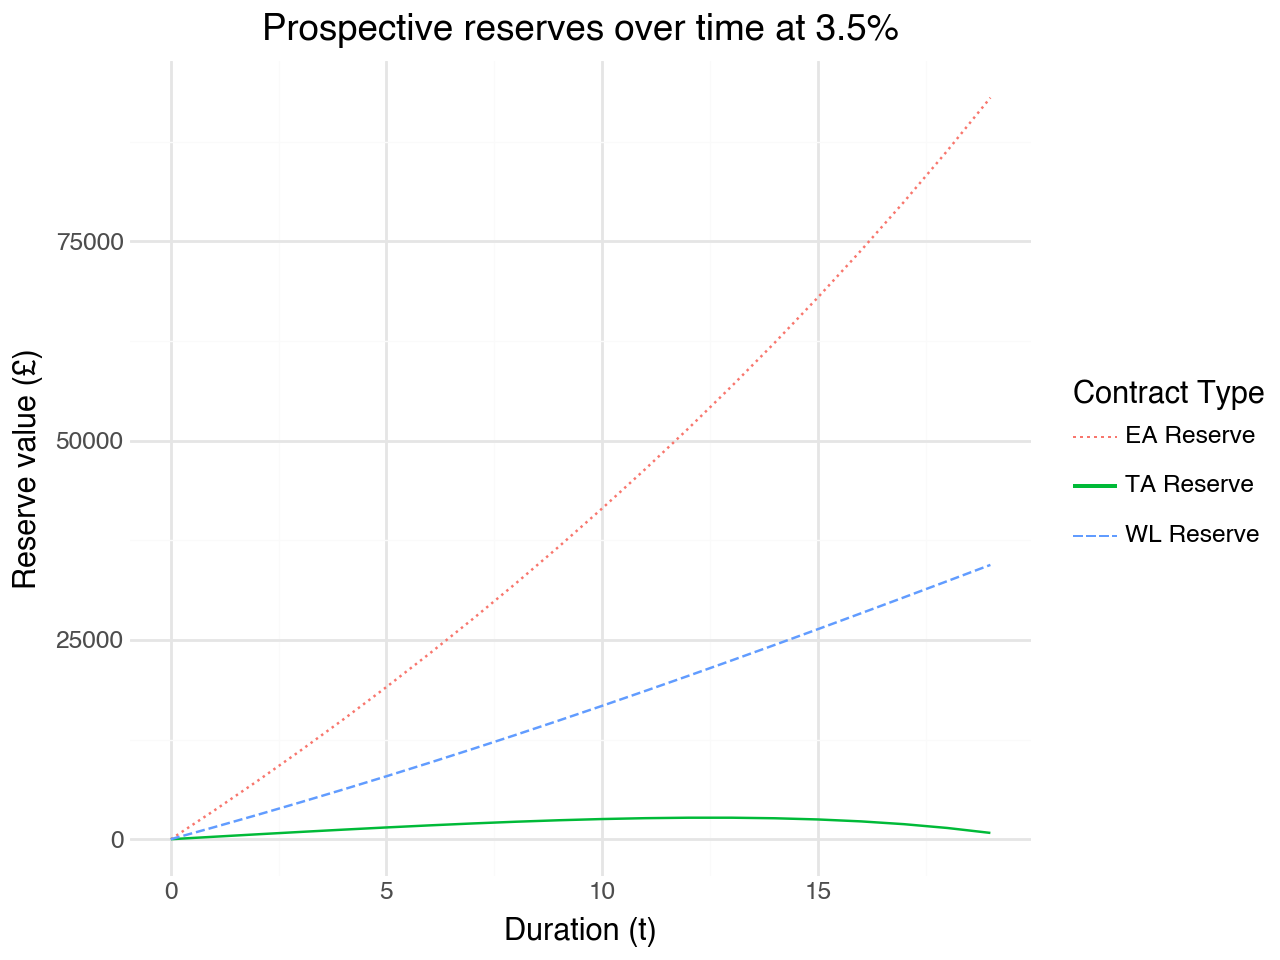

In [ ]:
# ==========================================
# Question 5: Reserving at 3.5%
# ==========================================
t_values = np.arange(0, 20)
reserves_WL = []
reserves_TA = []
reserves_EA = []

for t in t_values:
    curr_age = age + t

    # Lookup values at duration t using the 3.5% basis
    # BE note: can ignore pylance editor warning for below
    #   potentially look to remove in future
    D_x_t = comm_35.loc[curr_age, "D_x"]
    N_x_t = comm_35.loc[curr_age, "N_x"]
    M_x_t = comm_35.loc[curr_age, "M_x"]

    # WL Reserve
    v_wl = sum_assured * (M_x_t / D_x_t) - P_WL * (N_x_t / D_x_t)
    reserves_WL.append(v_wl)

    # TA and EA Reserves (only valid if term remains)
    if curr_age < maturity_age:
        A_TA_t = (M_x_t - M_65) / D_x_t
        A_EA_t = (M_x_t - M_65 + D_65) / D_x_t
        a_term_t = (N_x_t - N_65) / D_x_t

        v_ta = sum_assured * A_TA_t - P_TA * a_term_t
        v_ea = sum_assured * A_EA_t - P_EA * a_term_t
    else:
        v_ta = 0
        v_ea = sum_assured

    reserves_TA.append(v_ta)
    reserves_EA.append(v_ea)

# Output Table
df_reserves = pd.DataFrame(
    {
        "Duration (t)": t_values,
        "WL Reserve": reserves_WL,
        "TA Reserve": reserves_TA,
        "EA Reserve": reserves_EA,
    }
)
display(df_reserves.round(2))

# Melt the dataframe into Long/Tidy format for plotnine
df_melted = df_reserves.melt(
    id_vars=["Duration (t)"],
    value_vars=["WL Reserve", "TA Reserve", "EA Reserve"],
    var_name="Contract Type",
    value_name="Reserve Value (£)",
)

# Plotting with plotnine
reserve_plot = (
    ggplot(
        df_melted,
        aes(
            x="Duration (t)",
            y="Reserve Value (£)",
            color="Contract Type",
            # shape="Contract Type",
            linetype="Contract Type",
        ),
    )
    + geom_line()
    + scale_linetype_manual(
        values={
            "WL Reserve": "dashed",
            "TA Reserve": "solid",
            "EA Reserve": "dotted",
        }
    )
    # + geom_point(size=2.5)
    + theme_minimal()
    + labs(
        title="Prospective reserves over time at 3.5%",
        x="Duration (t)",
        y="Reserve value (£)",
    )
)
reserve_plot

## Question 6
